# Local Entropy Search (LES): Minimal 2D Walkthrough

- Contributors: avrohr
- Last updated: Apr 7, 2026
- BoTorch version: 0.1.dev2476+ga74cf943c (commit a74cf943c0bbe5f90e6050b757ecfdfcc21522ad)

This notebook gives a minimal, visual introduction to **Local Entropy Search (LES)** from:

David Stenger, Armin Lindicke, Alexander von Rohr, Sebastian Trimpe.
*Local Entropy Search over Descent Sequences for Bayesian Optimization*. ICLR 2026.
https://openreview.net/forum?id=cPxmLZmFa7


## 1. LES in One Minute

LES scores a candidate point by expected information gain about **local descent behavior** around an incumbent:

1. Draw posterior function paths.
2. From the incumbent, run gradient descent on each sampled path to get a descent sequence.
3. Condition the GP on these virtual sequence observations.
4. Compute mutual information as predictive entropy reduction at the candidate.

In this notebook we visualize: (i) true objective + gradients + true descent sequence,
(ii) GP mean + sampled LES sequences, and (iii) LES acquisition contour.


In [65]:
import warnings

import matplotlib.pyplot as plt
import torch
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms import Standardize
from botorch.test_functions.synthetic import Branin
from botorch.utils.transforms import unnormalize
from gpytorch.mlls import ExactMarginalLogLikelihood

from botorch_community.acquisition.local_entropy_search import LocalEntropySearch

warnings.filterwarnings("ignore")
torch.manual_seed(0)

device = torch.device("cpu")
dtype = torch.double
tkwargs = {"device": device, "dtype": dtype}

print(f"Device: {device}")
print(f"Dtype: {dtype}")


Device: cpu
Dtype: torch.float64


In [66]:
# Work in normalized [0, 1]^2, but evaluate true Branin in its native domain.
true_function = Branin(negate=False).to(**tkwargs)
true_bounds = true_function.bounds.to(**tkwargs)
unit_bounds = torch.stack([torch.zeros(2, **tkwargs), torch.ones(2, **tkwargs)])


def evaluate_objective(X_unit: torch.Tensor) -> torch.Tensor:
    X_orig = unnormalize(X_unit, bounds=true_bounds)
    return true_function(X_orig).unsqueeze(-1)


def make_grid(n: int = 120):
    x1 = torch.linspace(0.0, 1.0, n, **tkwargs)
    x2 = torch.linspace(0.0, 1.0, n, **tkwargs)
    X1, X2 = torch.meshgrid(x1, x2, indexing="xy")
    X = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=-1)
    return X1, X2, X


def compute_gradient_field(X: torch.Tensor) -> torch.Tensor:
    X_var = X.clone().detach().requires_grad_(True)
    y = evaluate_objective(X_var).squeeze(-1)
    (grad,) = torch.autograd.grad(y.sum(), X_var)
    return grad.detach()


def true_descent_sequence(x0: torch.Tensor, steps: int = 45, lr: float = 0.01) -> torch.Tensor:
    # Run descent in true Branin coordinates to avoid oversized steps in normalized space.
    x_orig = unnormalize(x0.unsqueeze(0), bounds=true_bounds).squeeze(0).detach().to(**tkwargs)
    sequence = [x0.clone().detach().to(**tkwargs)]
    for _ in range(steps):
        x_var = x_orig.clone().detach().requires_grad_(True)
        loss = true_function(x_var.unsqueeze(0)).sum()
        (grad,) = torch.autograd.grad(loss, x_var)
        with torch.no_grad():
            x_orig = (x_var - lr * grad).clamp(min=true_bounds[0], max=true_bounds[1])
            x_unit = (x_orig - true_bounds[0]) / (true_bounds[1] - true_bounds[0])
        sequence.append(x_unit.clone())
    return torch.stack(sequence, dim=0)


## 2. Fit a Small GP and Build LES


In [67]:
# A small training set for the surrogate model.
n_init = 8
train_X = torch.rand(n_init, 2, **tkwargs)
train_Y = evaluate_objective(train_X)

model = SingleTaskGP(
    train_X=train_X,
    train_Y=train_Y,
    outcome_transform=Standardize(m=1),
)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)
model.eval()
model.likelihood.eval()

incumbent = torch.tensor([[0.5, 0.5]]) #train_X[torch.argmin(train_Y.squeeze(-1))].unsqueeze(0)
print(f"Incumbent: {incumbent.squeeze(0).tolist()}")

les = LocalEntropySearch(
    model=model,
    x_incumbent=incumbent,
    num_path_samples=128,
    num_descent_steps=256,
    learning_rate=2e-3,
    maximize=False,
    bounds=unit_bounds,
    sequence_discretization_size=8,
    sequence_subsample_size=None,
    conditional_model_chunk_size=8,
    convergence_tol=1e-6,
)


Incumbent: [0.5, 0.5]


In [68]:
# Prepare fields for the three panels.
X1, X2, X_grid = make_grid(n=120)

with torch.no_grad():
    y_true = evaluate_objective(X_grid).reshape_as(X1)
    gp_mean = model.posterior(X_grid.unsqueeze(-2)).mean.squeeze(-1).squeeze(-1).reshape_as(X1)
    les_values = les(X_grid.unsqueeze(-2)).reshape_as(X1)

# Start the true descent sequence from the exact same incumbent as LES sequences.
x0 = incumbent.squeeze(0).detach()
true_path = true_descent_sequence(x0=x0, steps=128, lr=0.01)

G1, G2, G = make_grid(n=25)
grad = compute_gradient_field(G).reshape(25, 25, 2)

# Show the ground-truth gradient field with normalized arrows for readability.
grad_norm = torch.linalg.norm(grad, dim=-1, keepdim=True).clamp_min(1e-12)
grad_unit = -grad / grad_norm
U = grad_unit[..., 0]
V = grad_unit[..., 1]


## 3. Minimal Three-Panel Visualization


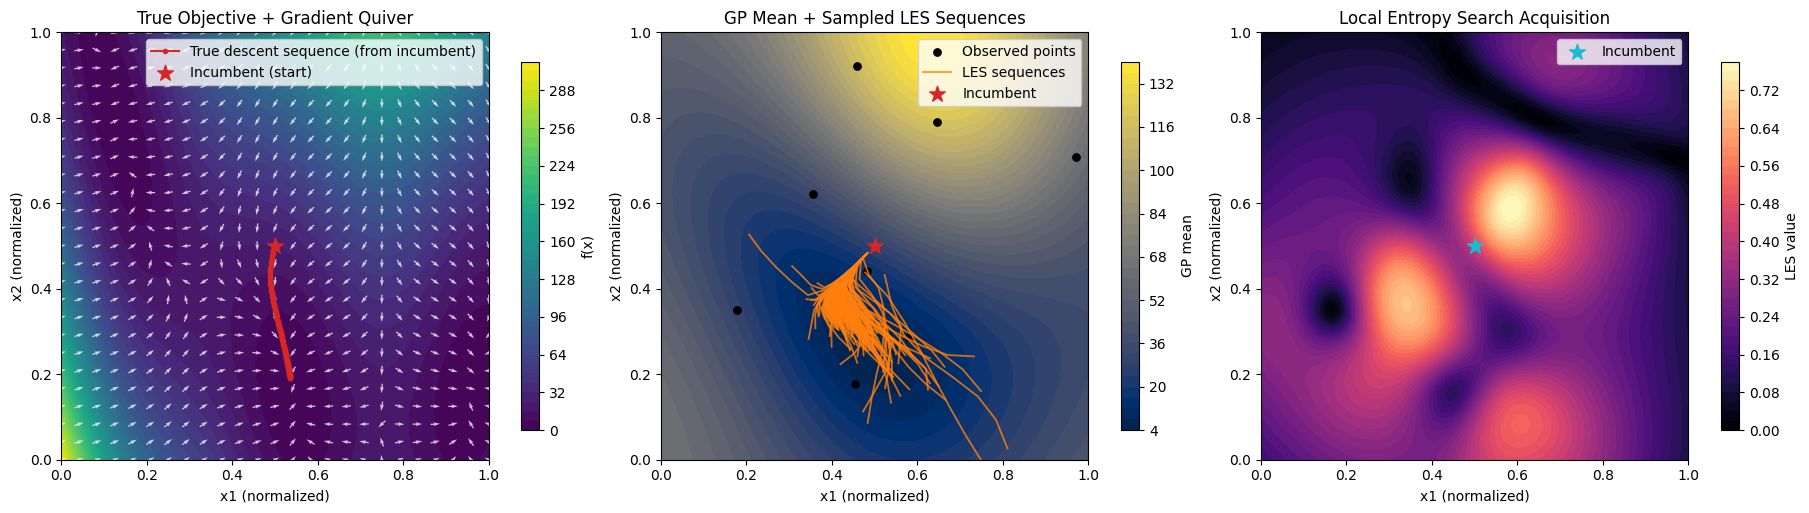

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Panel 1: True landscape + gradient quiver + true descent sequence
cf0 = axes[0].contourf(X1.cpu(), X2.cpu(), y_true.cpu(), levels=40, cmap="viridis")
axes[0].quiver(
    G1.cpu(),
    G2.cpu(),
    U.cpu(),
    V.cpu(),
    color="white",
    alpha=0.75,
    angles="xy",
    scale_units="xy",
    width=0.003,
    pivot="mid",
)
axes[0].plot(
    true_path[:, 0].cpu(),
    true_path[:, 1].cpu(),
    "-o",
    color="tab:red",
    markersize=3,
    linewidth=1.5,
    label="True descent sequence (from incumbent)",
)
axes[0].scatter(
    [x0[0].cpu()],
    [x0[1].cpu()],
    marker="*",
    s=140,
    color="tab:red",
    label="Incumbent (start)",
)
axes[0].set_title("True Objective + Gradient Quiver")
axes[0].set_xlabel("x1 (normalized)")
axes[0].set_ylabel("x2 (normalized)")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect("equal")
axes[0].legend(loc="upper right")
fig.colorbar(cf0, ax=axes[0], shrink=0.82, label="f(x)")

# Panel 2: GP mean + observations + sampled LES sequences
cf1 = axes[1].contourf(X1.cpu(), X2.cpu(), gp_mean.cpu(), levels=40, cmap="cividis")
axes[1].scatter(
    train_X[:, 0].cpu(),
    train_X[:, 1].cpu(),
    color="black",
    s=28,
    label="Observed points",
)

num_seq_to_plot = min(128, len(les.sequence_X_per_path))
for i in range(0, num_seq_to_plot):
    seq = les.sequence_X_per_path[i].detach().cpu()
    axes[1].plot(
        seq[:, 0],
        seq[:, 1],
        color="tab:orange",
        alpha=0.8,
        linewidth=1.3,
        label="LES sequences" if i == 0 else None,
    )

axes[1].scatter(
    [incumbent[0, 0].cpu()],
    [incumbent[0, 1].cpu()],
    marker="*",
    s=140,
    color="tab:red",
    label="Incumbent",
)
axes[1].set_title("GP Mean + Sampled LES Sequences")
axes[1].set_xlabel("x1 (normalized)")
axes[1].set_ylabel("x2 (normalized)")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect("equal")
axes[1].legend(loc="upper right")
fig.colorbar(cf1, ax=axes[1], shrink=0.82, label="GP mean")

# Panel 3: LES acquisition contour
cf2 = axes[2].contourf(X1.cpu(), X2.cpu(), les_values.cpu(), levels=40, cmap="magma")
axes[2].scatter(
    [incumbent[0, 0].cpu()],
    [incumbent[0, 1].cpu()],
    marker="*",
    s=140,
    color="tab:cyan",
    label="Incumbent",
)
axes[2].set_title("Local Entropy Search Acquisition")
axes[2].set_xlabel("x1 (normalized)")
axes[2].set_ylabel("x2 (normalized)")
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].set_aspect("equal")
axes[2].legend(loc="upper right")
fig.colorbar(cf2, ax=axes[2], shrink=0.82, label="LES value")

plt.show()


## 4. LES in action

For this notebook we keep the incumbent fixed to visualize entropy reduction along LES sequences over iterations. However, in practice it makes sense to update the incumbent, for example, using the best observation or the argmin of the posterior mean in the noisy setting.

In each iteration record:


- **Query**: argmax of LES acquisition (this is what gets evaluated and added).
- **Proposal**: argmin of GP posterior mean (diagnostic recommendation).



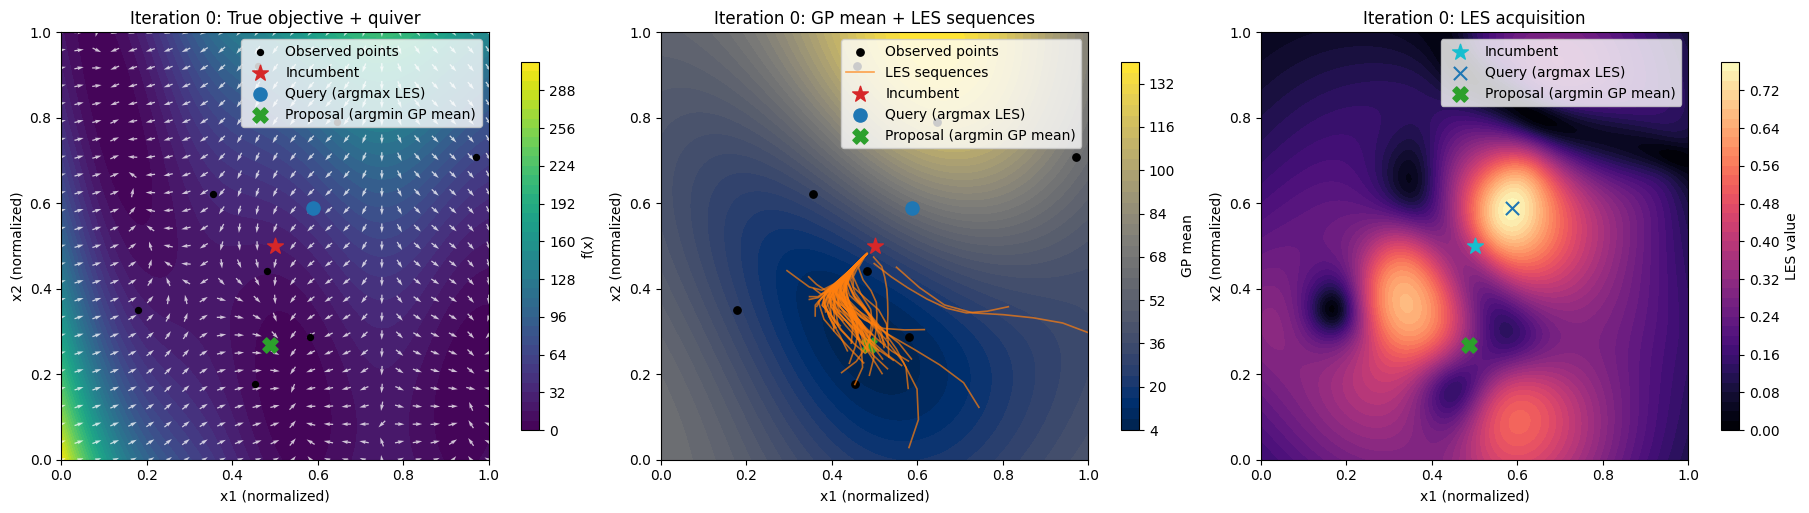

Iteration 0: query_x=[0.5882352941176471, 0.5882352941176471], query_y=51.8295, proposal_y=4.5683, best_y=7.9946


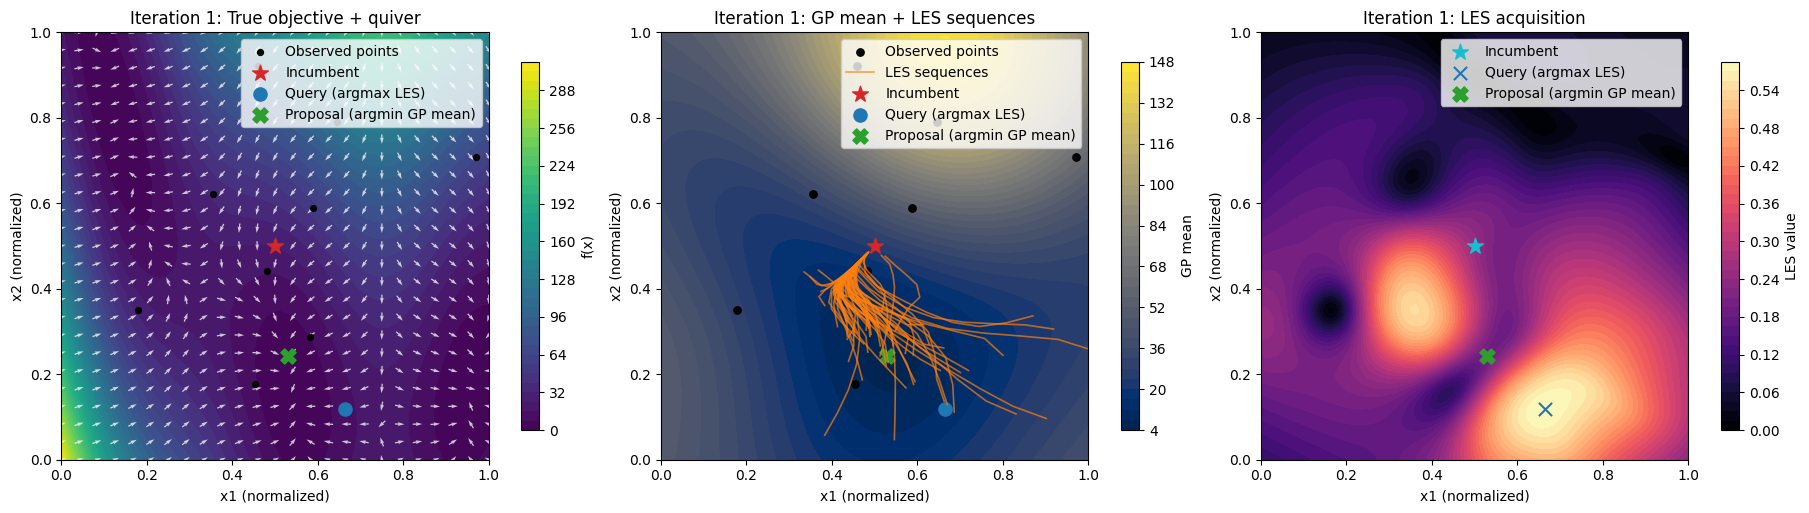

Iteration 1: query_x=[0.6638655462184874, 0.11764705882352941], query_y=12.5650, proposal_y=2.0760, best_y=7.9946


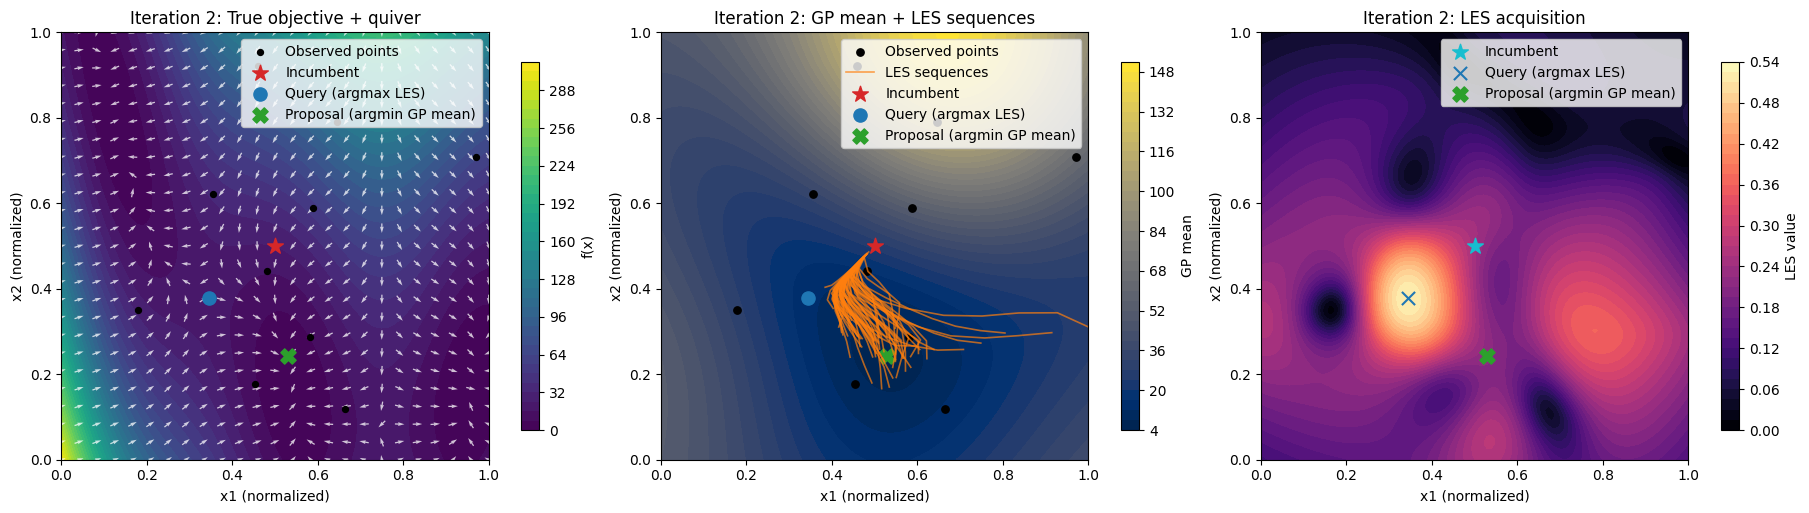

Iteration 2: query_x=[0.3445378151260504, 0.37815126050420167], query_y=19.4709, proposal_y=2.0760, best_y=7.9946


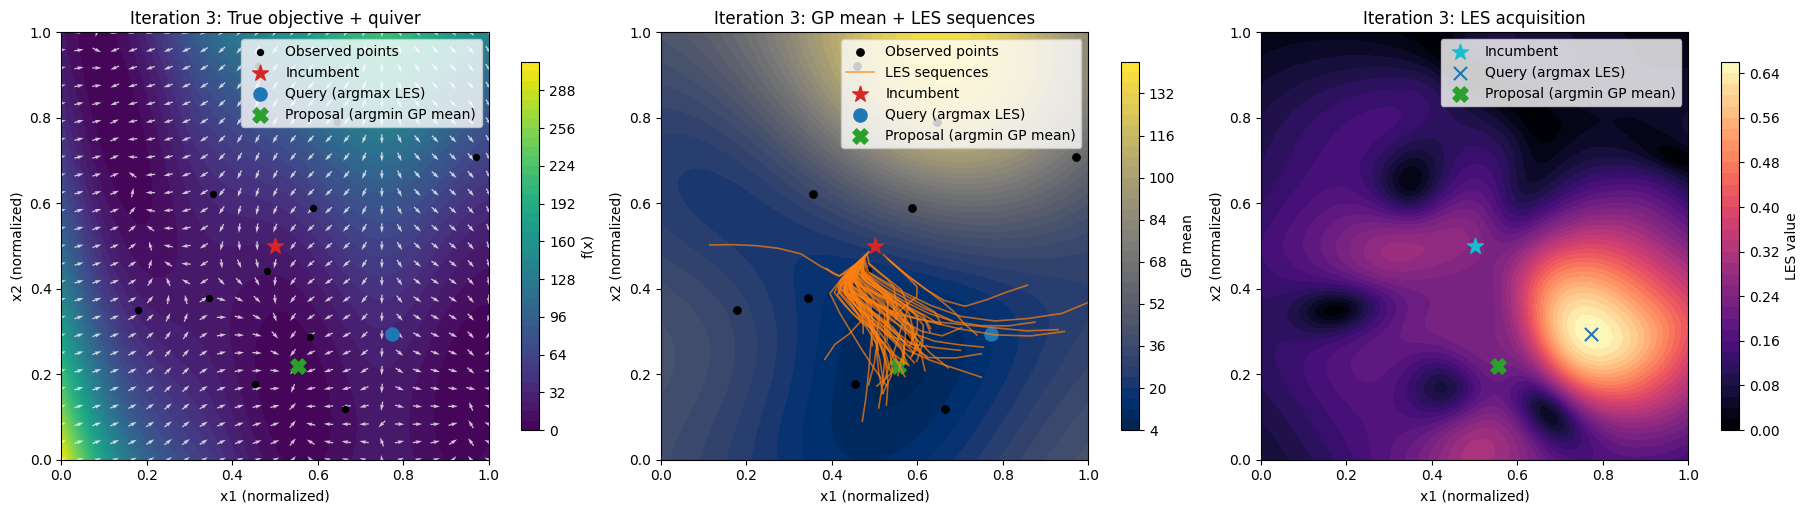

Iteration 3: query_x=[0.773109243697479, 0.29411764705882354], query_y=29.9524, proposal_y=1.8416, best_y=7.9946


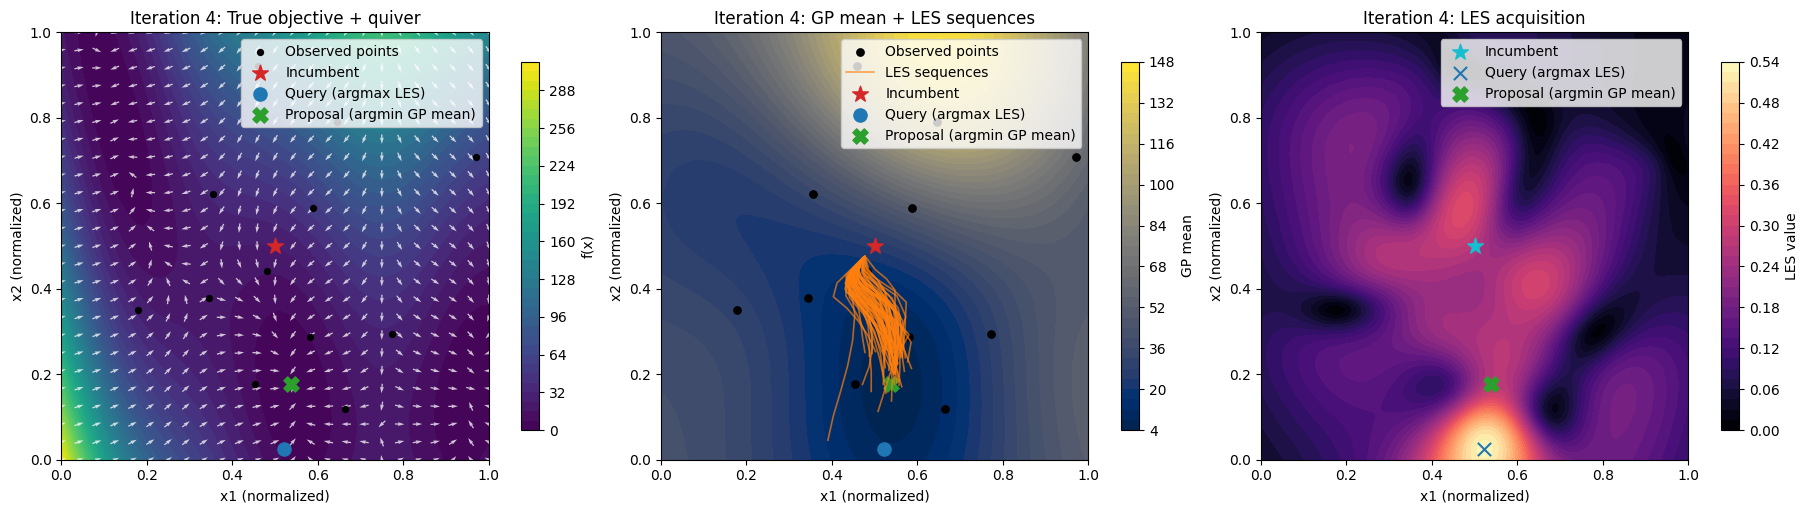

Iteration 4: query_x=[0.5210084033613446, 0.025210084033613446], query_y=5.5932, proposal_y=0.5226, best_y=5.5932


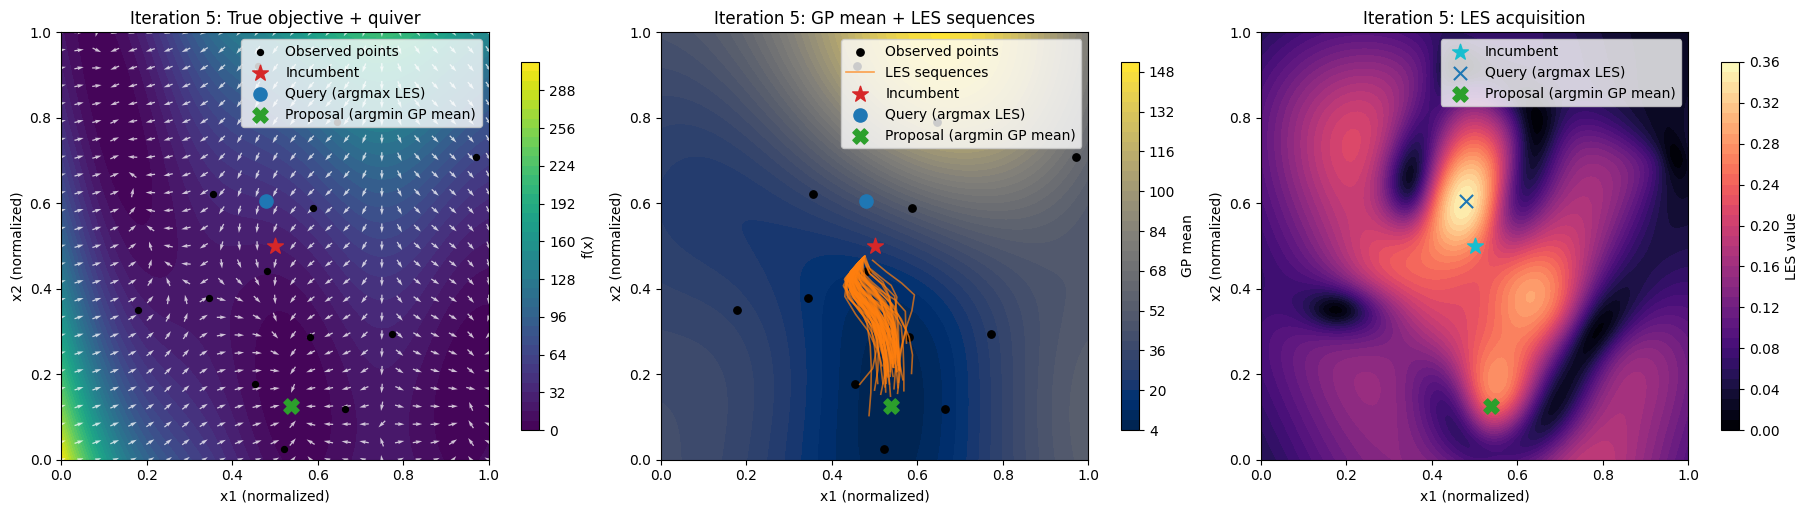

Iteration 5: query_x=[0.4789915966386554, 0.6050420168067228], query_y=39.7066, proposal_y=0.6206, best_y=5.5932


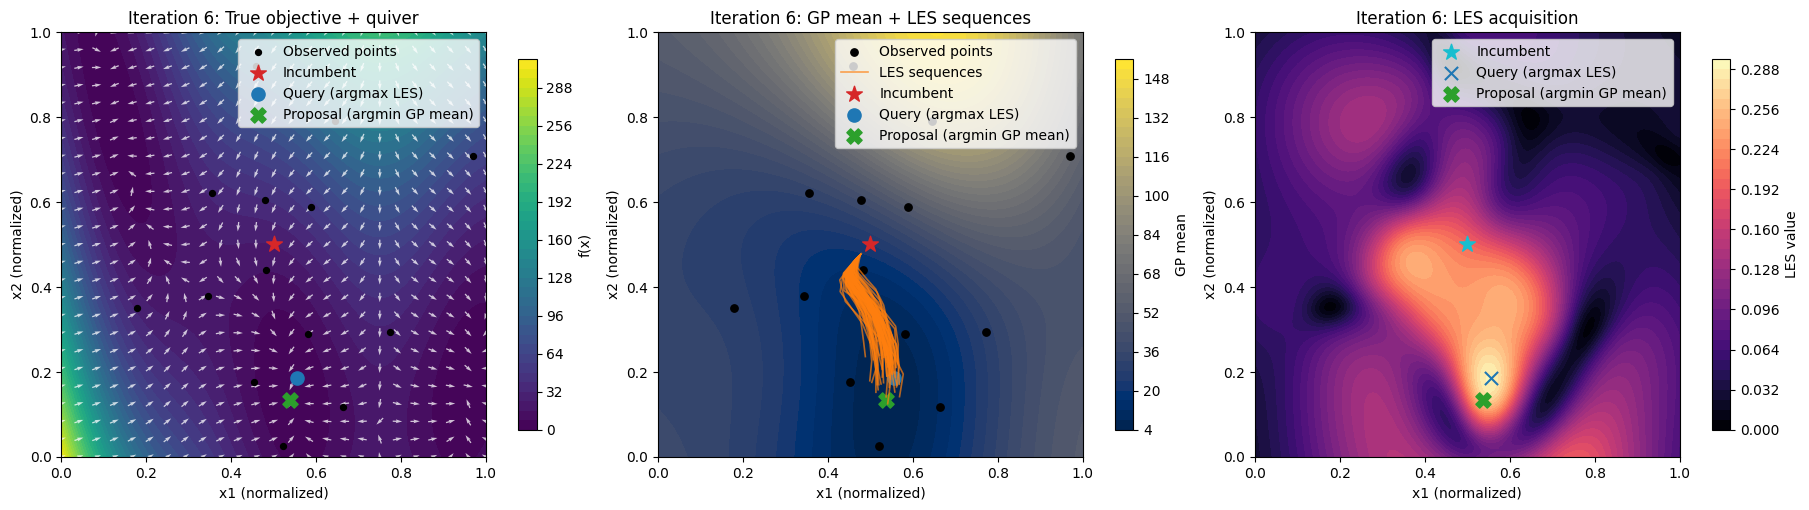

Iteration 6: query_x=[0.5546218487394958, 0.18487394957983191], query_y=0.9494, proposal_y=0.5249, best_y=0.9494


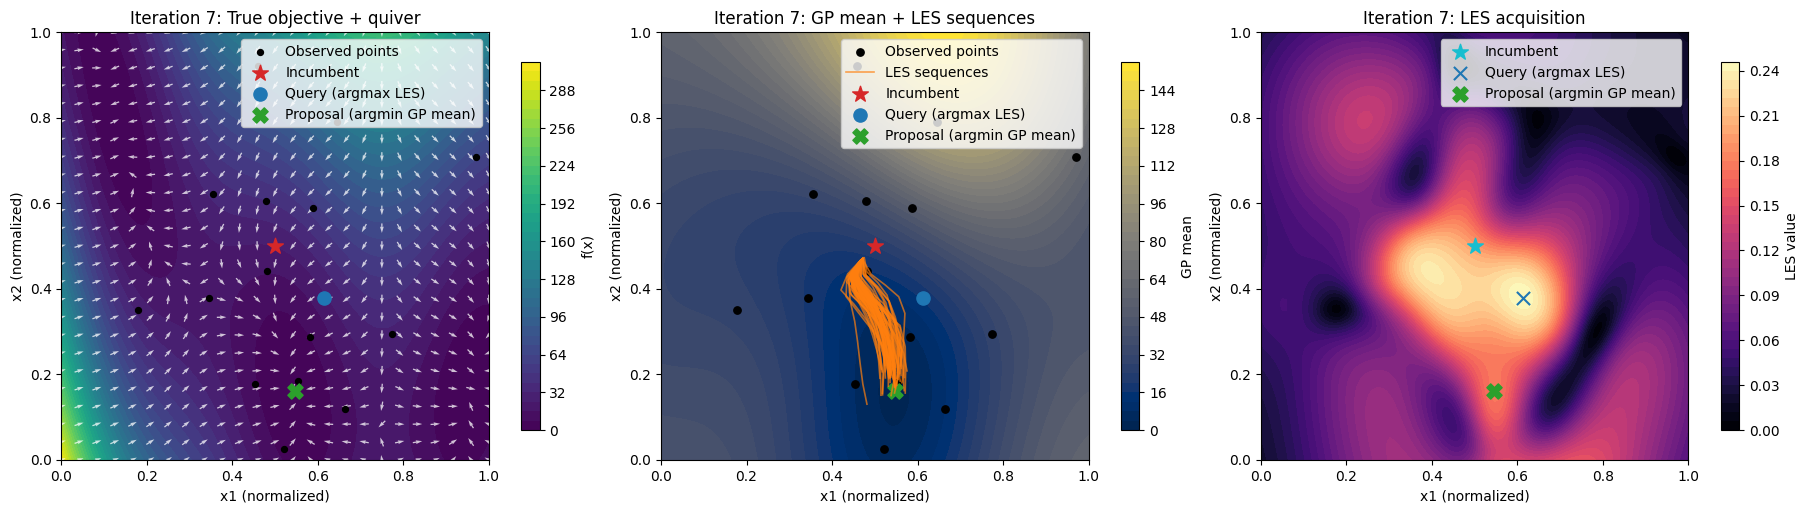

Iteration 7: query_x=[0.6134453781512605, 0.37815126050420167], query_y=21.9432, proposal_y=0.4363, best_y=0.9494


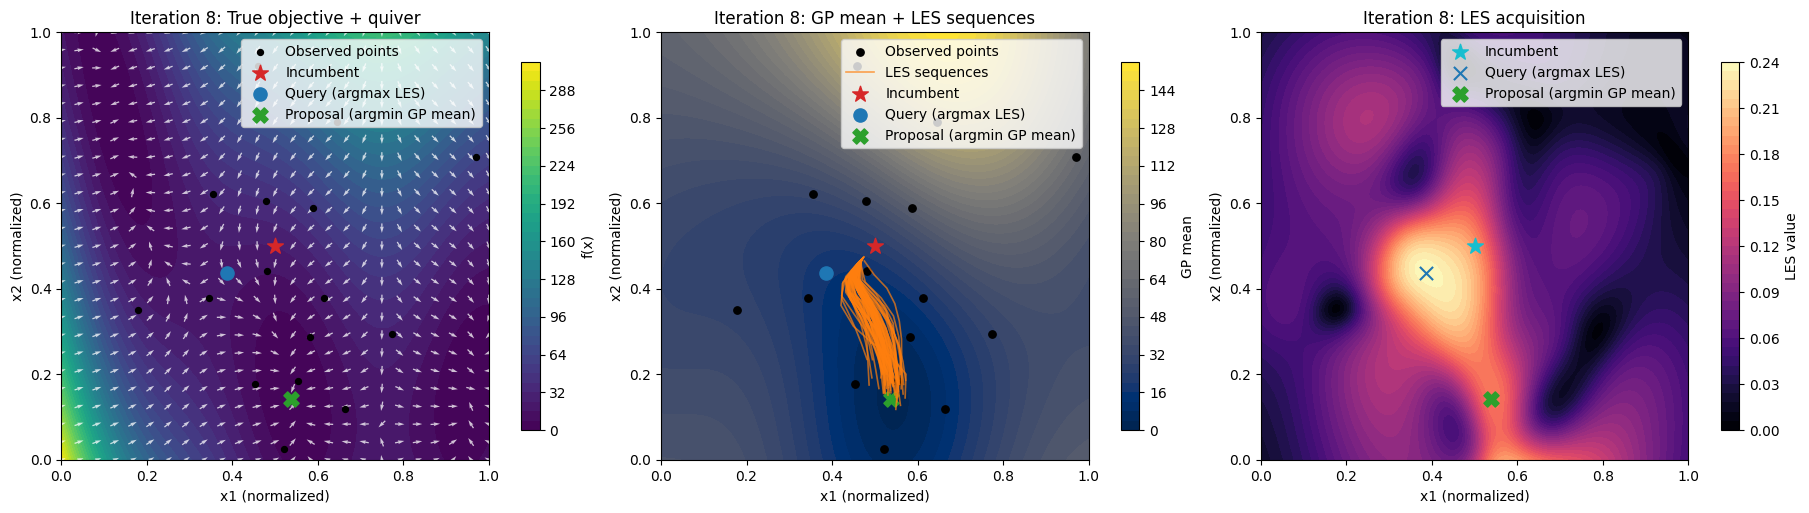

Iteration 8: query_x=[0.38655462184873945, 0.4369747899159664], query_y=19.7390, proposal_y=0.4609, best_y=0.9494


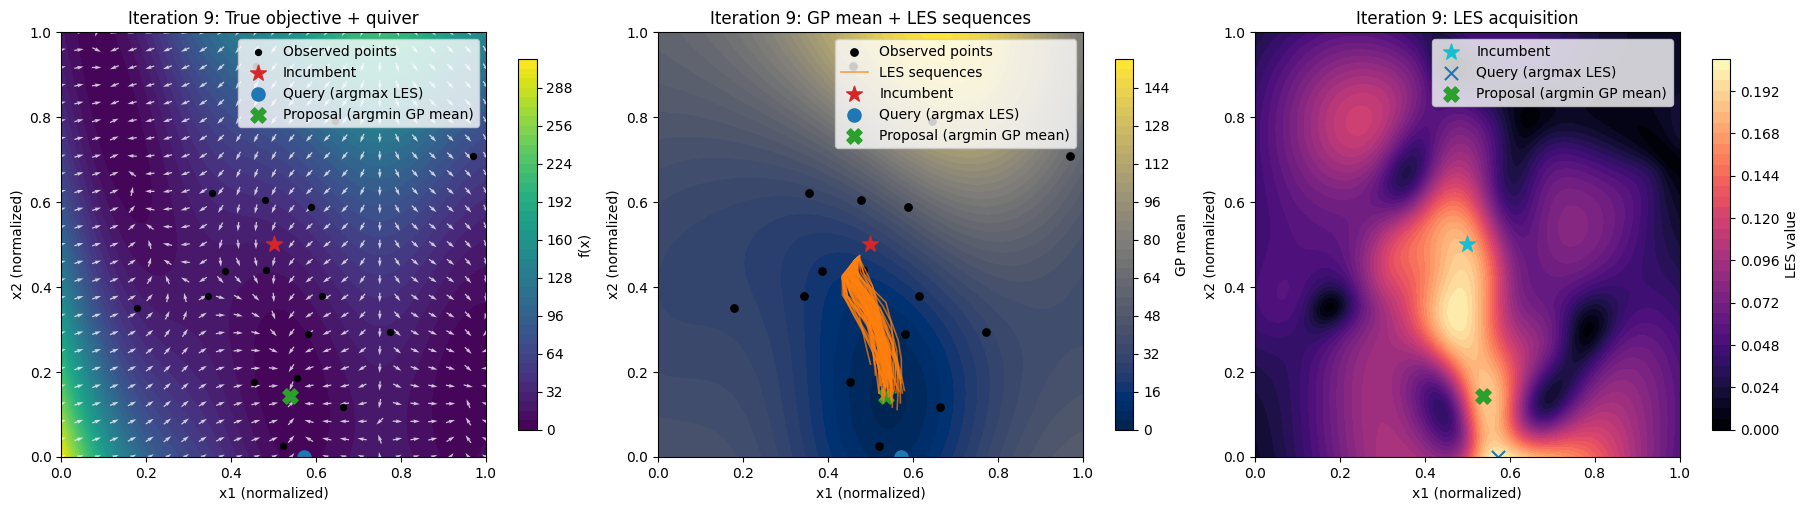

Iteration 9: query_x=[0.5714285714285714, 0.0], query_y=5.1273, proposal_y=0.4609, best_y=0.9494


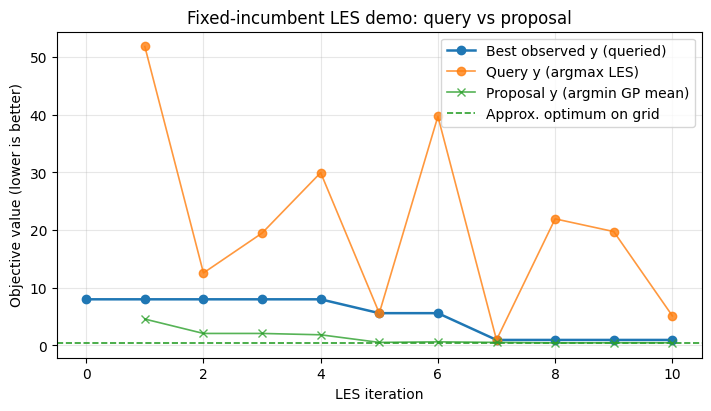

In [70]:
# Closed-loop LES demonstration settings.
n_bo_steps = 10

# Start from a small initial set for a clearer iterative visualization.
bo_train_X = train_X.clone()
bo_train_Y = train_Y.clone()

# Reuse fixed grids for plotting / proposal selection.
PX1, PX2, PX = make_grid(n=120)
Q1, Q2, Q = make_grid(n=25)

with torch.no_grad():
    true_obj_grid = evaluate_objective(PX).reshape_as(PX1)

grad_q = compute_gradient_field(Q).reshape(25, 25, 2)
grad_q_norm = torch.linalg.norm(grad_q, dim=-1, keepdim=True).clamp_min(1e-12)
descent_q = -grad_q / grad_q_norm
Uq = descent_q[..., 0]
Vq = descent_q[..., 1]

# Performance tracking.
query_y_history: list[float] = []
proposal_y_history: list[float] = []
best_y_history: list[float] = [float(bo_train_Y.min().item())]

for iteration in range(n_bo_steps):
    # Refit GP on current data.
    model_iter = SingleTaskGP(
        train_X=bo_train_X,
        train_Y=bo_train_Y,
        outcome_transform=Standardize(m=1),
    )
    mll_iter = ExactMarginalLogLikelihood(model_iter.likelihood, model_iter)
    fit_gpytorch_mll(mll_iter)
    model_iter.eval()
    model_iter.likelihood.eval()

    # In this notebook we keep the incumbent fixed to highlight entropy reduction.
    incumbent_iter = torch.tensor([[0.5, 0.5]], **tkwargs)
    # Full algorithm variant: update incumbent from current best observation or argmin of the posterior mean.
    # incumbent_iter = bo_train_X[torch.argmin(bo_train_Y.squeeze(-1))].unsqueeze(0)

    les_iter = LocalEntropySearch(
        model=model_iter,
        x_incumbent=incumbent_iter,
        num_path_samples=64,
        num_descent_steps=256,
        learning_rate=2e-3,
        maximize=False,
        bounds=unit_bounds,
        sequence_discretization_size=8
    )

    with torch.no_grad():
        gp_mean_iter = model_iter.posterior(PX.unsqueeze(-2)).mean.squeeze(-1).squeeze(-1)
        gp_mean_iter = gp_mean_iter.reshape_as(PX1)
        les_values_iter = les_iter(PX.unsqueeze(-2)).reshape_as(PX1)

    # Query: argmax LES acquisition over the dense evaluation grid.
    les_values_flat = les_values_iter.reshape(-1)
    dist_query = torch.cdist(PX, bo_train_X).min(dim=1).values
    unseen_query_mask = dist_query > 1e-9
    if torch.any(unseen_query_mask):
        les_values_masked = les_values_flat.clone()
        les_values_masked[~unseen_query_mask] = -torch.inf
        query_idx = torch.argmax(les_values_masked)
    else:
        query_idx = torch.argmax(les_values_flat)
    query_x = PX[query_idx].unsqueeze(0)
    query_y = evaluate_objective(query_x)

    # Proposal: argmin GP posterior mean over dense grid.
    gp_mean_flat = gp_mean_iter.reshape(-1)
    dist_prop = torch.cdist(PX, bo_train_X).min(dim=1).values
    unseen_prop_mask = dist_prop > 1e-9
    if torch.any(unseen_prop_mask):
        gp_mean_masked = gp_mean_flat.clone()
        gp_mean_masked[~unseen_prop_mask] = torch.inf
        proposal_idx = torch.argmin(gp_mean_masked)
    else:
        proposal_idx = torch.argmin(gp_mean_flat)
    proposal_x = PX[proposal_idx].unsqueeze(0)
    proposal_y = evaluate_objective(proposal_x)

    # Plot true objective + quiver, GP + sequences, and LES acquisition.
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    # Panel 1: True objective + quiver (no true descent sequence).
    cf_true = axes[0].contourf(PX1.cpu(), PX2.cpu(), true_obj_grid.cpu(), levels=40, cmap="viridis")
    axes[0].quiver(
        Q1.cpu(),
        Q2.cpu(),
        Uq.cpu(),
        Vq.cpu(),
        color="white",
        alpha=0.75,
        angles="xy",
        scale_units="xy",
        width=0.003,
        pivot="mid",
    )
    axes[0].scatter(bo_train_X[:, 0].cpu(), bo_train_X[:, 1].cpu(), color="black", s=18, label="Observed points")
    axes[0].scatter([incumbent_iter[0, 0].cpu()], [incumbent_iter[0, 1].cpu()], marker="*", s=140, color="tab:red", label="Incumbent")
    axes[0].scatter([query_x[0, 0].cpu()], [query_x[0, 1].cpu()], marker="o", s=90, color="tab:blue", label="Query (argmax LES)")
    axes[0].scatter([proposal_x[0, 0].cpu()], [proposal_x[0, 1].cpu()], marker="X", s=120, color="tab:green", label="Proposal (argmin GP mean)")
    axes[0].set_title(f"Iteration {iteration}: True objective + quiver")
    axes[0].set_xlabel("x1 (normalized)")
    axes[0].set_ylabel("x2 (normalized)")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].set_aspect("equal")
    axes[0].legend(loc="upper right")
    fig.colorbar(cf_true, ax=axes[0], shrink=0.82, label="f(x)")

    # Panel 2: GP mean + observations + sampled LES sequences.
    cf_left = axes[1].contourf(PX1.cpu(), PX2.cpu(), gp_mean_iter.cpu(), levels=40, cmap="cividis")
    axes[1].scatter(bo_train_X[:, 0].cpu(), bo_train_X[:, 1].cpu(), color="black", s=28, label="Observed points")

    num_seq_total = len(les_iter.sequence_X_per_path)
    # seq_stride = max(1, num_seq_total // 16)
    for i in range(0, num_seq_total):
        seq = les_iter.sequence_X_per_path[i].detach().cpu()
        axes[1].plot(
            seq[:, 0],
            seq[:, 1],
            color="tab:orange",
            alpha=0.7,
            linewidth=1.2,
            label="LES sequences" if i == 0 else None,
        )

    axes[1].scatter([incumbent_iter[0, 0].cpu()], [incumbent_iter[0, 1].cpu()], marker="*", s=140, color="tab:red", label="Incumbent")
    axes[1].scatter([query_x[0, 0].cpu()], [query_x[0, 1].cpu()], marker="o", s=90, color="tab:blue", label="Query (argmax LES)")
    axes[1].scatter([proposal_x[0, 0].cpu()], [proposal_x[0, 1].cpu()], marker="X", s=120, color="tab:green", label="Proposal (argmin GP mean)")
    axes[1].set_title(f"Iteration {iteration}: GP mean + LES sequences")
    axes[1].set_xlabel("x1 (normalized)")
    axes[1].set_ylabel("x2 (normalized)")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].set_aspect("equal")
    axes[1].legend(loc="upper right")
    fig.colorbar(cf_left, ax=axes[1], shrink=0.82, label="GP mean")

    # Panel 3: LES acquisition contour.
    cf_right = axes[2].contourf(PX1.cpu(), PX2.cpu(), les_values_iter.cpu(), levels=40, cmap="magma")
    axes[2].scatter([incumbent_iter[0, 0].cpu()], [incumbent_iter[0, 1].cpu()], marker="*", s=140, color="tab:cyan", label="Incumbent")
    axes[2].scatter([query_x[0, 0].cpu()], [query_x[0, 1].cpu()], marker="x", s=90, color="tab:blue", label="Query (argmax LES)")
    axes[2].scatter([proposal_x[0, 0].cpu()], [proposal_x[0, 1].cpu()], marker="X", s=120, color="tab:green", label="Proposal (argmin GP mean)")
    axes[2].set_title(f"Iteration {iteration}: LES acquisition")
    axes[2].set_xlabel("x1 (normalized)")
    axes[2].set_ylabel("x2 (normalized)")
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1)
    axes[2].set_aspect("equal")
    axes[2].legend(loc="upper right")
    fig.colorbar(cf_right, ax=axes[2], shrink=0.82, label="LES value")

    plt.show()

    # Update data only with queried point (algorithmic query). 
    bo_train_X = torch.cat([bo_train_X, query_x], dim=0)
    bo_train_Y = torch.cat([bo_train_Y, query_y], dim=0)

    query_y_history.append(float(query_y.item()))
    proposal_y_history.append(float(proposal_y.item()))
    best_y_history.append(float(bo_train_Y.min().item()))

    print(
        f"Iteration {iteration}: query_x={query_x.squeeze(0).tolist()}, "
        f"query_y={float(query_y.item()):.4f}, proposal_y={float(proposal_y.item()):.4f}, "
        f"best_y={float(bo_train_Y.min().item()):.4f}"
    )

# Performance plot for the fixed-incumbent variant.
fig, ax = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
ax.plot(list(range(0, n_bo_steps + 1)), best_y_history, marker="o", linewidth=1.8, label="Best observed y (queried)")
ax.plot(list(range(1, n_bo_steps + 1)), query_y_history, marker="o", linewidth=1.2, alpha=0.8, label="Query y (argmax LES)")
ax.plot(list(range(1, n_bo_steps + 1)), proposal_y_history, marker="x", linewidth=1.2, alpha=0.8, label="Proposal y (argmin GP mean)")
ax.axhline(float(true_obj_grid.min().item()), color="tab:green", linestyle="--", linewidth=1.2, label="Approx. optimum on grid")
ax.set_xlabel("LES iteration")
ax.set_ylabel("Objective value (lower is better)")
ax.set_title("Fixed-incumbent LES demo: query vs proposal")
ax.grid(alpha=0.3)
ax.legend(loc="upper right")
plt.show()
